# Retrieval Grading: Assessing Document Relevance [Step 24 - Retrieval Grading]

> **MLCourse - Agentic AI - Corrective RAG**

A RAG pipeline is only as good as the documents it retrieves. If the retrieved
chunks are irrelevant, the generator will produce poor answers. This notebook
builds a grading chain that evaluates each retrieved document for relevance
to the user query. The grade helps the pipeline decide whether to proceed
with generation or re-retrieve.

### What you will learn

1. How to build a chain that scores document relevance.
2. How to define grading criteria for retrieved chunks.
3. How to use grades to filter low-quality retrievals.
4. How grading integrates into a corrective RAG pipeline.

## 1. Setup

In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## 2. Ingest Alice and Build Vector Store

In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print(f"[ingest] chunks: {len(documents)} | retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | retriever ready (k=4)


## 3. Initialize the LLM

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


## 4. Define Grading Criteria
The grader evaluates each document against the query using three criteria:
- **Relevance**: Does the document address the query topic?
- **Sufficiency**: Does the document contain enough information to answer?
- **Quality**: Is the document well-formed and coherent?

In [4]:
GRADING_PROMPT_TEMPLATE = """You are a strict document relevance grader for a RAG system.
Given the user QUERY and a RETRIEVED DOCUMENT, evaluate the document on three criteria:

1. RELEVANCE: Does the document address the query topic? (0-10)
2. SUFFICIENCY: Does the document contain enough information to answer the query? (0-10)
3. QUALITY: Is the document well-formed and coherent? (0-10)

Provide an overall GRADE (0-10) and a brief JUSTIFICATION.

Reply in EXACTLY this format:
GRADE: <number>
JUSTIFICATION: <one sentence>"""

print("[grader] prompt template defined")

[grader] prompt template defined


## 5. Build the Grading Chain
The chain takes a query and a document, formats them into the prompt, and
returns the grade and justification.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def build_grading_chain():
    """Build a chain that grades a document against a query."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", GRADING_PROMPT_TEMPLATE),
        ("user", "QUERY: {query}\n\nDOCUMENT:\n{document}")
    ])
    return prompt | llm | StrOutputParser()

grading_chain = build_grading_chain()
print("[grader] chain built")

[grader] chain built


## 6. Grade a Single Document
Test the grading chain on one retrieved chunk.

In [6]:
query = "What happened when Alice fell down the rabbit hole?"
docs = retriever.invoke(query)
doc = docs[0]

print(f"Query: {query}")
print(f"Document chunk {doc.metadata['chunk_id']}: {doc.page_content[:200]}...")
print()

result = grading_chain.invoke({"query": query, "document": doc.page_content})
print(f"Grading result:\n{result}")

Query: What happened when Alice fell down the rabbit hole?
Document chunk 4: In another moment down went Alice after it, never once considering how
in the world she was to get out again.

The rabbit-hole went straight on like a tunnel for some way, and then
dipped suddenly dow...



Grading result:
GRADE: 9
JUSTIFICATION: The document is highly relevant (10) as it directly addresses the query topic, sufficient (8) in providing detailed information about Alice's fall, and of high quality (9) with clear and coherent writing.


## 7. Grade Multiple Documents
Grade all retrieved chunks and collect the results.

In [7]:
def grade_documents(query: str, documents: list) -> list:
    """Grade each document against the query and return results."""
    grades = []
    for i, doc in enumerate(documents):
        result = grading_chain.invoke({"query": query, "document": doc.page_content})
        grade_match = re.search(r"GRADE:\s*(\d+(?:\.\d+)?)", result)
        grade = float(grade_match.group(1)) if grade_match else 0.0
        justification_match = re.search(r"JUSTIFICATION:\s*(.+)", result)
        justification = justification_match.group(1).strip() if justification_match else ""
        grades.append({
            "chunk_id": doc.metadata.get("chunk_id", i),
            "grade": grade,
            "justification": justification,
            "content": doc.page_content[:150],
        })
        print(f"  Chunk {doc.metadata.get('chunk_id', i)}: grade={grade:.1f} | {justification}")
    return grades

print("=" * 60)
print("GRADING DOCUMENTS FOR QUERY:")
print(f"  {query}")
print("=" * 60)
grades = grade_documents(query, docs)

GRADING DOCUMENTS FOR QUERY:
  What happened when Alice fell down the rabbit hole?


  Chunk 4: grade=9.0 | The document is highly relevant as it directly addresses the query topic, provides sufficient information about Alice's fall down the rabbit hole, and is well-written with clear descriptions of events.


  Chunk 3: grade=8.0 | The document is highly relevant to the query topic, but lacks sufficient information to fully answer it, as it only describes the initial event of Alice falling down the rabbit hole and does not provide any further context or explanation.


  Chunk 39: grade=6.0 | The document is relevant to the query topic, but lacks sufficient information about what happened when Alice fell down the rabbit hole, and its quality is compromised by grammatical errors and a narrative tone that doesn't provide clear answers.


  Chunk 15: grade=8.0 | The document is highly relevant and sufficient in addressing the query topic, providing a detailed account of Alice's experience falling down the rabbit hole, but its quality is somewhat diminished by minor grammatical errors and an abrupt ending.


## 8. Filter by Grade Threshold
Documents below the threshold are discarded. The remaining ones are
used for generation.

In [8]:
def filter_documents(grades: list, threshold: float = 5.0) -> list:
    """Return only documents above the grade threshold."""
    passed = [g for g in grades if g["grade"] >= threshold]
    failed = [g for g in grades if g["grade"] < threshold]
    print(f"  Passed: {len(passed)} | Failed: {len(failed)} | Threshold: {threshold}")
    return passed

print("=" * 60)
print("FILTERING WITH THRESHOLD = 5.0")
print("=" * 60)
passed = filter_documents(grades, threshold=5.0)
for g in passed:
    print(f"  Chunk {g['chunk_id']}: {g['content'][:100]}...")

FILTERING WITH THRESHOLD = 5.0
  Passed: 4 | Failed: 0 | Threshold: 5.0
  Chunk 4: In another moment down went Alice after it, never once considering how
in the world she was to get o...
  Chunk 3: on, Alice started to her feet, for it flashed across her mind that she
had never before seen a rabbi...
  Chunk 39: Oh dear, what nonsense I’m talking!”

Just then her head struck against the roof of the hall: in fac...
  Chunk 15: Alice was not a bit hurt, and she jumped up on to her feet in a moment:
she looked up, but it was al...


## 9. Build the Grading Node for LangGraph
This function wraps the grading logic into a node that can be used
in a LangGraph state machine.

In [9]:
from typing import TypedDict

class GradingState(TypedDict):
    query: str
    context: str
    documents: list
    grades: list
    passed_documents: list
    grade_threshold: float

def grade_documents_node(state: GradingState) -> dict:
    """LangGraph node that grades all retrieved documents."""
    query = state["query"]
    doc_strings = state["context"].split("\n\n")
    
    grades = []
    passed = []
    for i, doc_text in enumerate(doc_strings):
        if not doc_text.strip():
            continue
        result = grading_chain.invoke({"query": query, "document": doc_text})
        grade_match = re.search(r"GRADE:\s*(\d+(?:\.\d+)?)", result)
        grade = float(grade_match.group(1)) if grade_match else 0.0
        justification_match = re.search(r"JUSTIFICATION:\s*(.+)", result)
        justification = justification_match.group(1).strip() if justification_match else ""
        
        grade_info = {
            "chunk_id": i,
            "grade": grade,
            "justification": justification,
        }
        grades.append(grade_info)
        
        if grade >= state.get("grade_threshold", 5.0):
            passed.append({"chunk_id": i, "content": doc_text, "grade": grade})
        
        print(f"  [grade] chunk {i}: {grade:.1f} | {justification}")
    
    print(f"  [grade] passed: {len(passed)}/{len(grades)}")
    return {"grades": grades, "passed_documents": passed}

print("[node] grade_documents_node defined")

[node] grade_documents_node defined


## 10. Test the Grading Node
Run the grading node on a sample query and inspect the results.

In [10]:
test_query = "What did the Cheshire Cat say to Alice?"
test_docs = retriever.invoke(test_query)
test_context = "\n\n".join(d.page_content for d in test_docs)

test_state = {
    "query": test_query,
    "context": test_context,
    "documents": test_docs,
    "grades": [],
    "passed_documents": [],
    "grade_threshold": 5.0,
}

print("=" * 60)
print("TESTING GRADING NODE")
print("=" * 60)
result = grade_documents_node(test_state)
print(f"\nGrades: {result['grades']}")
print(f"Passed documents: {len(result['passed_documents'])}")

TESTING GRADING NODE


  [grade] chunk 0: 6.0 | The document is somewhat relevant as it mentions Dinah, Alice's cat, but does not directly address the query about what the Cheshire Cat said to Alice.


  [grade] chunk 1: 2.0 | The document is marginally relevant to the query as it mentions Alice's conversation with herself, but does not contain any information about what the Cheshire Cat said.


  [grade] chunk 2: 2.0 | The document is relevant to the query topic, but it does not contain any information about what the Cheshire Cat said to Alice.


  [grade] chunk 3: 2.0 | The document is relevant to the query topic, but it does not provide enough information to answer the question and its quality is poor due to being a fragment of a sentence.


  [grade] chunk 4: 2.0 | The document is relevant to Alice's Adventures in Wonderland but does not address the specific query about what the Cheshire Cat said to her.


  [grade] chunk 5: 2.0 | The document is relevant to Alice's Adventures in Wonderland, but it does not address the specific query about what the Cheshire Cat said to Alice, and its content is insufficient for answering this question.
  [grade] passed: 1/6

Grades: [{'chunk_id': 0, 'grade': 6.0, 'justification': "The document is somewhat relevant as it mentions Dinah, Alice's cat, but does not directly address the query about what the Cheshire Cat said to Alice."}, {'chunk_id': 1, 'grade': 2.0, 'justification': "The document is marginally relevant to the query as it mentions Alice's conversation with herself, but does not contain any information about what the Cheshire Cat said."}, {'chunk_id': 2, 'grade': 2.0, 'justification': 'The document is relevant to the query topic, but it does not contain any information about what the Cheshire Cat said to Alice.'}, {'chunk_id': 3, 'grade': 2.0, 'justification': 'The document is relevant to the query topic, but it does not provide enough informa

## 11. Build a Mini Grading Graph
Demonstrate grading in a simple graph: retrieve -> grade -> decide.

In [11]:
from langgraph.graph import StateGraph, START, END

def retrieve_node(state: GradingState) -> dict:
    """Retrieve documents for the query."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    print(f"  [retrieve] {len(docs)} chunks fetched")
    return {"context": context, "documents": docs}

def route_by_grades(state: GradingState) -> str:
    """Route based on grading results."""
    if len(state["passed_documents"]) > 0:
        print("  [route] documents passed grading -> proceed")
        return "proceed"
    print("  [route] no documents passed grading -> re-retrieve or fallback")
    return "fallback"

graph = StateGraph(GradingState)
graph.add_node("retrieve", retrieve_node)
graph.add_node("grade", grade_documents_node)
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "grade")
graph.add_conditional_edges(
    "grade",
    route_by_grades,
    {"proceed": END, "fallback": END},
)
app = graph.compile()
print("[graph] grading graph compiled")

[graph] grading graph compiled


## 12. Visualize the Grading Graph

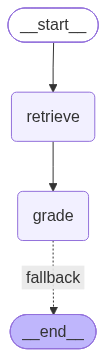

In [12]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> retrieve -> grade")
    print("    grade -> END (proceed or fallback)")

## 13. Run the Grading Graph

In [13]:
print("=" * 60)
print("RUNNING GRADING GRAPH")
print("=" * 60)
result = app.invoke({
    "query": "What happened when Alice fell down the rabbit hole?",
    "context": "",
    "documents": [],
    "grades": [],
    "passed_documents": [],
    "grade_threshold": 5.0,
})
print(f"\nPassed documents: {len(result['passed_documents'])}")
for g in result["grades"]:
    print(f"  Chunk {g['chunk_id']}: grade={g['grade']:.1f}")

RUNNING GRADING GRAPH
  [retrieve] 4 chunks fetched


  [grade] chunk 0: 8.0 | The document is highly relevant and sufficient in addressing the query topic, but its brevity detracts from its overall quality score.


  [grade] chunk 1: 9.0 | The document is highly relevant as it directly addresses the query topic, provides sufficient information about Alice's fall down the rabbit hole, and is well-written with clear and coherent language.


  [grade] chunk 2: 8.0 | The document is highly relevant to the query topic, but lacks sufficient information to fully answer it, as it only describes the initial event of Alice falling down the rabbit hole and does not provide any further context or explanation.


  [grade] chunk 3: 2.0 | The document is marginally relevant to the query topic, but it lacks sufficient information and is poorly formed.


  [grade] chunk 4: 8.0 | The document is highly relevant to the query topic, but lacks sufficient information to fully answer it, as it only describes a brief moment in Alice's journey down the rabbit hole rather than providing a comprehensive account of what happened.


  [grade] chunk 5: 4.0 | The document is relevant to the query topic, but it does not contain enough information about Alice's fall down the rabbit hole, instead focusing on her current situation after falling.


  [grade] chunk 6: 8.0 | The document is highly relevant and sufficient in addressing the query topic, providing a detailed account of Alice's experience after falling down the rabbit hole, but its quality is somewhat diminished by minor grammatical errors and an abrupt ending.
  [grade] passed: 5/7
  [route] documents passed grading -> proceed

Passed documents: 5
  Chunk 0: grade=8.0
  Chunk 1: grade=9.0
  Chunk 2: grade=8.0
  Chunk 3: grade=2.0
  Chunk 4: grade=8.0
  Chunk 5: grade=4.0
  Chunk 6: grade=8.0


## Summary

Key takeaways:
- Document grading evaluates relevance, sufficiency, and quality.
- The grading chain scores each document on a 0-10 scale.
- A threshold filters out low-quality documents before generation.
- Grading nodes integrate cleanly into LangGraph pipelines.
- Proper grading prevents the generator from working with bad context.